In [1]:
import numpy as np
import matplotlib.pyplot as plt


# (a)
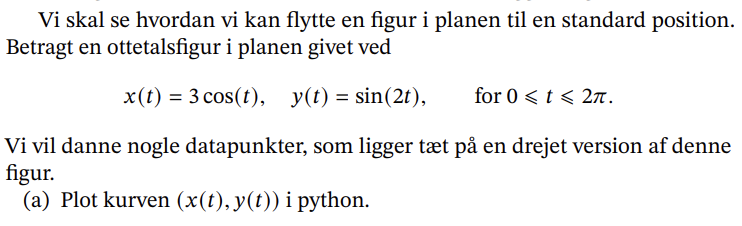

In [2]:
n = 2000

# Angivelse af t
t = np.linspace(0, 2 * np.pi, n)

# Angivelse af x og y
x = 3 * np.cos(t)
y = np.sin(2*t)

A_orig = np.vstack([x, y])

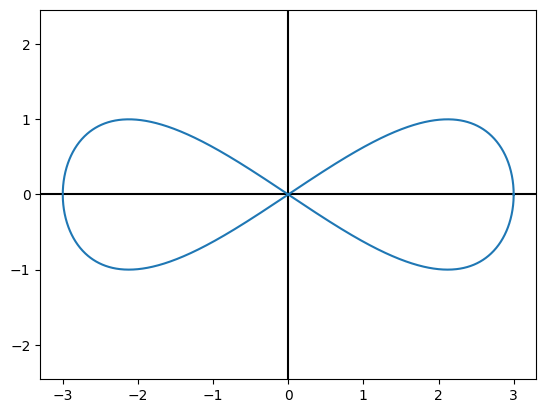

In [3]:
# Plot figure
fig, ax = plt.subplots()
ax.axis('equal')
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.plot(x, y)

# (b)

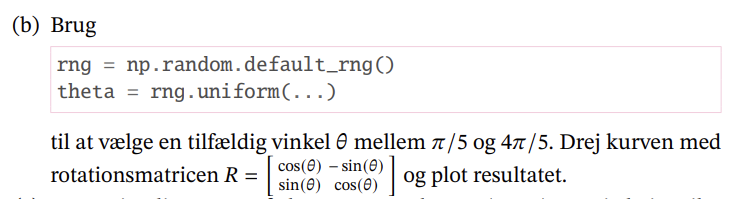

In [4]:
# Angivelse af tilfældig vinkel
rng = np.random.default_rng()
theta = rng.uniform(np.pi/5, 4*np.pi/5)

# Angivelse af rotationsmatrix
c = np.cos(theta)
s = np.sin(theta)
R = np.array([[c, -s],
              [s, c]])

A = np.vstack([x, y]) 

# Apply rotation matrix to A
A = R @ A

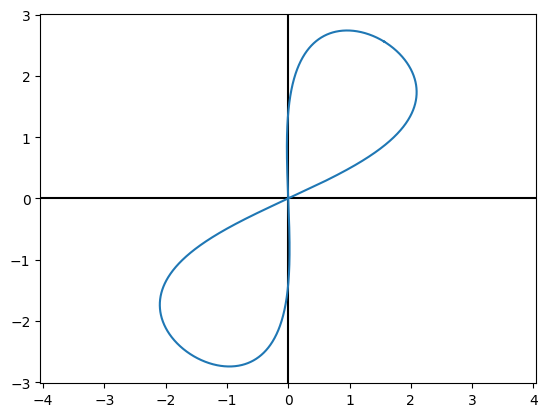

In [5]:
# Plot figure
fig, ax = plt.subplots()
ax.axis('equal')
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.plot(*A)

# (c)

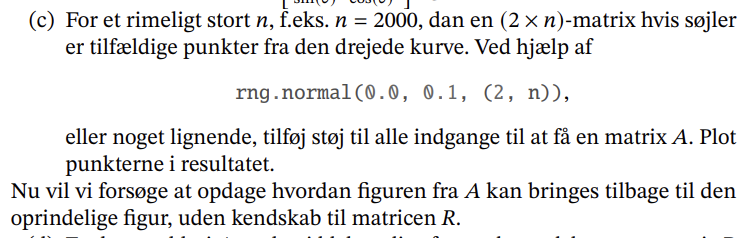

In [6]:
# Tilføjelse af støj til A
støj = rng.normal(0.0, 0.1, (2, n))
A = A + støj

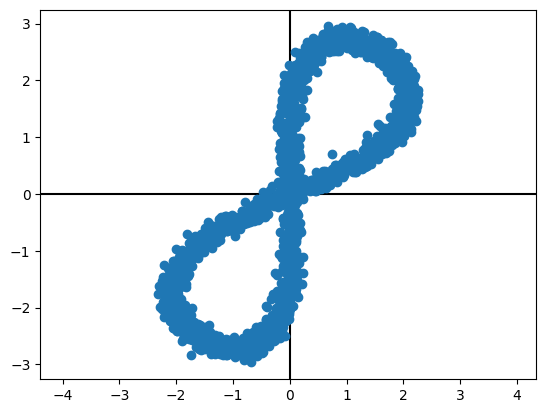

In [7]:
# Plot figure
fig, ax = plt.subplots()
ax.axis('equal')
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.plot(*A, 'o')

# (d)

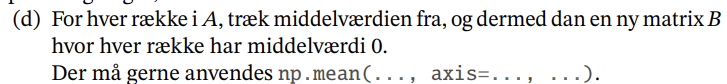

In [8]:
# Angivelse af antal rækker og søjler i A
n, m = A.shape

B = A

for i in range(n):
    print(np.mean(A[i]))
    B[i] -= np.mean(A[i])


0.0013682009404511462
0.0018803274272573844


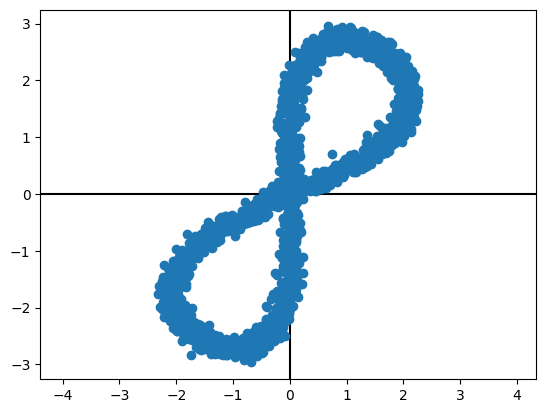

In [9]:
# Plot figure
fig, ax = plt.subplots()
ax.axis('equal')
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.plot(*B, 'o')

# (e)

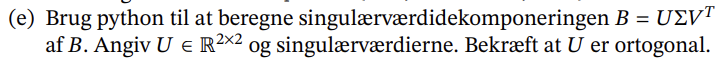

In [10]:
u, sigma, vt = np.linalg.svd(B, full_matrices=False)

sigma = np.diag(sigma)

In [11]:
u, sigma

(array([[-0.52326728, -0.85216862],
        [-0.85216862,  0.52326728]]),
 array([[94.87980693,  0.        ],
        [ 0.        , 31.82625044]]))

Hvis $U$ er ortogonal så må $U^T U = I_2$

In [12]:
u.T @ u

array([[1.00000000e+00, 1.23563449e-16],
       [1.23563449e-16, 1.00000000e+00]])

In [13]:
(sigma@vt).shape, vt

((2, 2000),
 array([[-0.02934677, -0.03123539, -0.03074407, ..., -0.03213965,
         -0.03321085, -0.03184367],
        [-0.00426286, -0.000771  ,  0.00015463, ..., -0.00418985,
          0.00190456,  0.00574714]]))

Alle indgangene der burde være $0$ er indenfor machine epsilon, og derfor må det gælde at samlingen er ortogonal.

# (f)
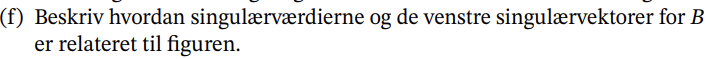

De venstre singulær vektorer beskriver på en måde hvilken retning punkterne skal strækkes i, og de tilhørende singulærværdier beskriver hvor meget de skal strækkes i de retninger.

Dette var vist i notesættet på følgende figur:

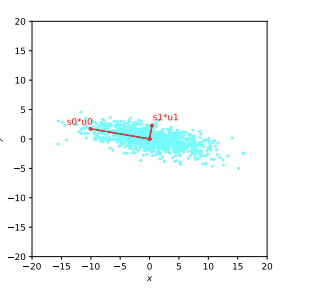

## (g)

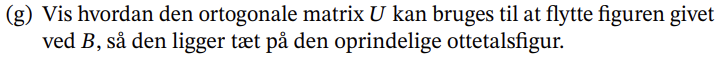

Hvis vi ændrer $U$ til identitetsmatricen, så skulle vi gerne få at akserne punkterne bliver strukkede på er netop x-aksen og y-aksen:

In [14]:
vtest = np.array([[1, 0, 1/np.sqrt(2)],
                  [0, 1, 1/np.sqrt(2)]])
A_recreated = np.eye(2) @ np.diag(sigma) @ vt
A_recreated

array([-2.92008707, -2.98814583, -2.9120698 , ..., -3.18275057,
       -3.09042441, -2.83841163])

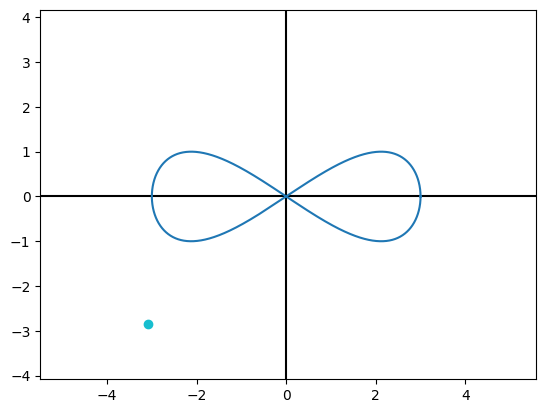

In [15]:
# Plot figure
fig, ax = plt.subplots()
ax.axis('equal')
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.plot(*A_recreated, 'o')
ax.plot(*A_orig)